# Эгосеть друзей вконтакте. Гофман Сергей МКЛНГ241

## Импорты

In [3]:
import vk_api
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.metrics import normalized_mutual_info_score
import pandas as pd
from cdlib import algorithms
from cdlib import evaluation

Note: to be able to use all crisp methods, you need to install some additional packages:  {'leidenalg', 'bayanpy', 'infomap', 'graph_tool'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'pyclustering', 'ASLPAw'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'leidenalg', 'infomap'}


## Подготовка данных

### Подключение к вк

Я создал свое приложение в среде vk и получил access_token.

In [7]:
ACCESS_TOKEN = 'vk1.a.tt7wqFpt5a5Hs950v0SEUBlIhhV8wIrhW1LuN5yCkfkDoRR2hKelUTOV2KK1m_PI63BCrjQ5VRMJeSpw6UZorBd2pgPKCzIa6ThjbKNjjynjVl-mptfVLtXDo_3l8qYVUDjSaSgyIERHBhFFyigfFm_bTV1HRFpz5kRRszyww4M1uZ7TalOM2NYIZiL8aM9vY7J74p3Ia2tYDcLY9ltzCg'

Подключился к vk_api.

In [9]:
vk_session = vk_api.VkApi(token = ACCESS_TOKEN)
vk = vk_session.get_api()

В Вк апи, насколько я понял, можно использовать числовой айди. Получу его по своему никнейму.

In [11]:
vk.users.get(user_ids = 'serezhkag')

[{'id': 190275230,
  'first_name': 'Сережа',
  'last_name': 'Гофман',
  'can_access_closed': True,
  'is_closed': False}]

In [12]:
my_id = vk.users.get(user_ids = 'serezhkag')[0]['id']

## Работа с данными

### Сбор данных.

Вершины – мои друзья.

Наличие ребра между вершинами говорит о том, что люди находятся друг у друга в друзьях.

Граф неориентированный.

Достану друзей со своей страницы. Буду подписывать вершины именем и фамилией.

In [17]:
friends_info = {}
friends_ids = set()

#vk.friends.get возвращает словарь с ключами count и items
#нас интересует только ключ items (тоже словарь с информацией о людях), в котором обязательно должны быть ключи first_name,last_name
friends = vk.friends.get(user_id = my_id, fields = 'first_name,last_name')['items']
friends[0]

{'id': 2854772,
 'lists': [29],
 'track_code': 'f515693eUJKGWU01S346BMJTMVrL2gQSKibUNdd8YF0PNra5JOch7oxVdzEWJjxYwofOzm3qKkNqSdw6wWRaQ2ZFwuY',
 'first_name': 'Ирина',
 'last_name': 'Шек',
 'can_access_closed': True,
 'is_closed': False}

In [18]:
for friend in friends:
    friend_id = friend['id']
    name = f"{friend.get('first_name', '')} {friend.get('last_name', '')}".strip()
    friends_info[friend_id] = name
    friends_ids.add(friend_id)

### Создание графа

Создам вершины.

In [21]:
G = nx.Graph()
for friend_id, name in friends_info.items():
    G.add_node(friend_id, label = name)

Создам ребра.

Надо учесть, что у некоторых людей закрытые аккаунты и автоматически нельзя будет получить информацию об их друзьях.

Оберну все в try-except.

Код в ячейке берет друга №1, получает id всех его друзей, находит пересечения с id всех моих друзей и добавляет в граф ребро между другом №1 и всеми друзьями, которые попали в пересечение множеств моих друзей и друзей друга №1. Цикл повторяется для каждого моего друга, о котором удалось получить информацию.

In [23]:
for friend1 in friends_info:
    try:
        friend1friends = vk.friends.get(user_id = friend1, fields = 'id')
        friend1friends_ids = {item['id'] for item in friend1friends['items']}
        friendship = friend1friends_ids.intersection(friends_ids)

        for friend2 in friendship:
            if friend1 != friend2:
                G.add_edge(friend1, friend2)
                
    except vk_api.exceptions.ApiError as e:
        continue

Инфо о графе.

In [25]:
print(f'В моем графе {G.number_of_nodes()} вершин и {G.number_of_edges()} ребер.')

В моем графе 132 вершин и 810 ребер.


### Визуализация графа

Визуализирую граф. Отдельно отмечу, что вершин у меня много, поэтому, чтобы подписи на них хоть как-то читались, "оттолкну" их друг от друга.

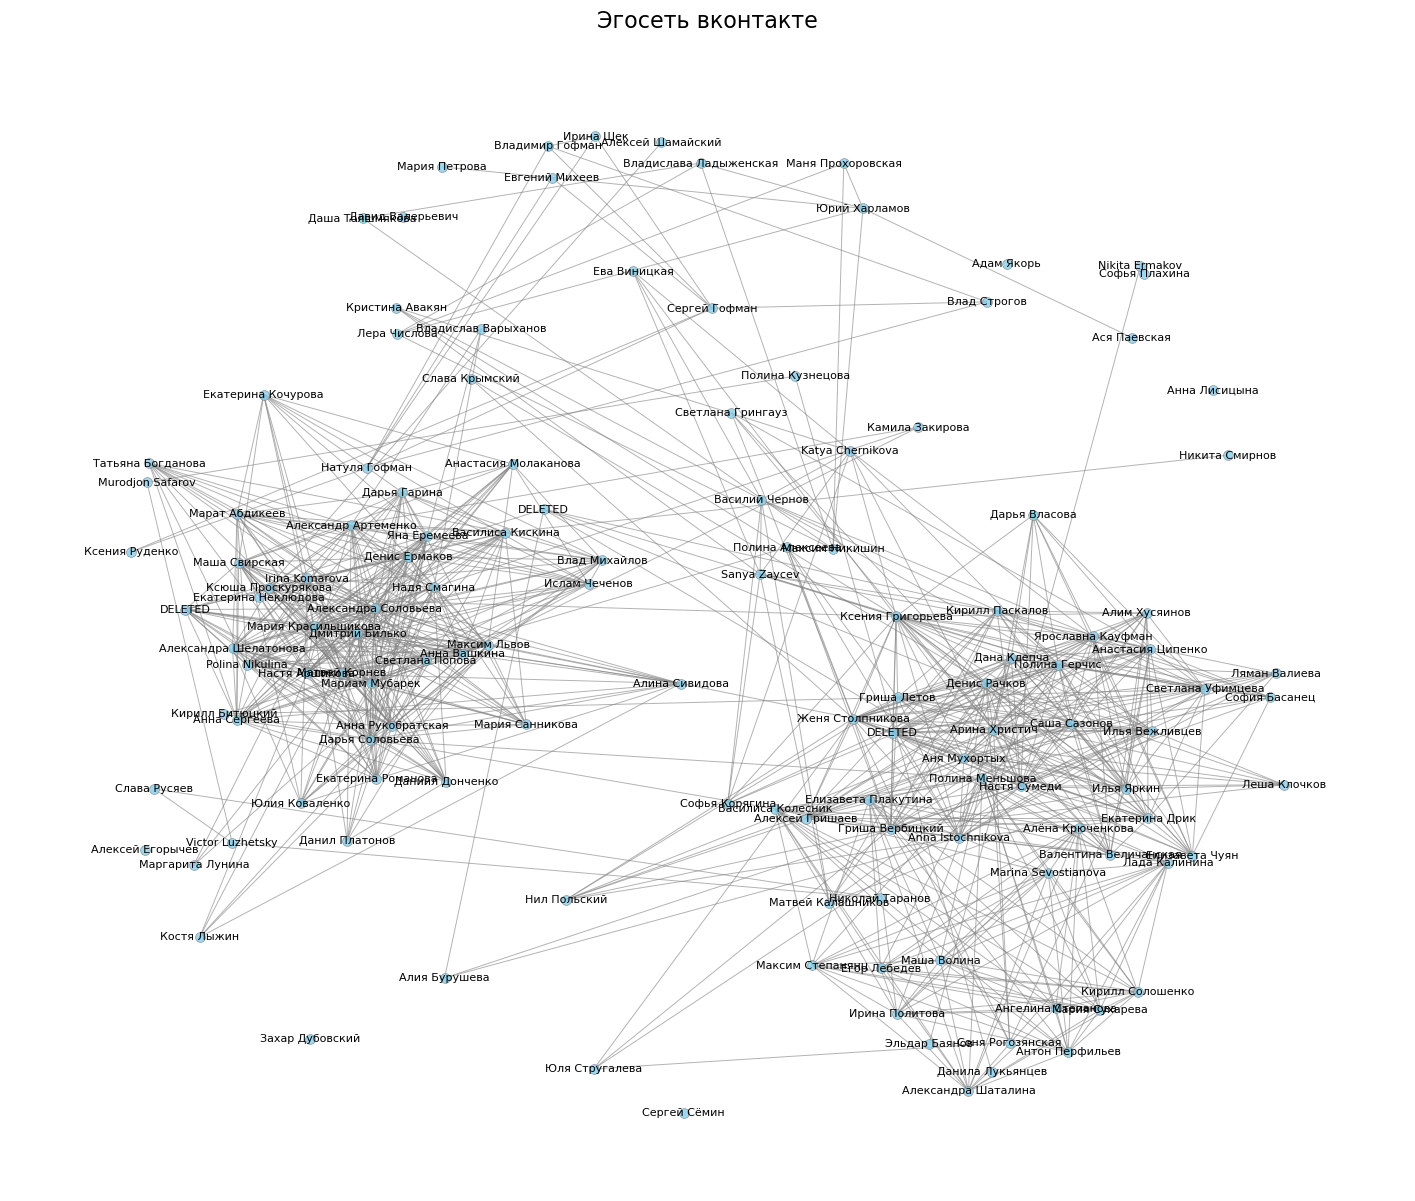

In [28]:
plt.figure(figsize=(18, 15))

#этот лейаут притянет более связанные узлы ближе, поэтому взял его
pos = nx.spring_layout(G, k = .8, seed = 42)

nx.draw_networkx_nodes(G, pos, node_size = 50, node_color = 'skyblue', alpha = .8, edgecolors = 'gray', linewidths = .5)

nx.draw_networkx_edges(G, pos, width = 0.7, edge_color = 'gray', alpha = 0.6)

labels = nx.get_node_attributes(G, 'label')
nx.draw_networkx_labels(G, pos, labels, font_size = 8, font_color = 'black')

plt.title('Эгосеть вконтакте', fontsize = 16)
plt.axis('off')
plt.show()

## Структурный анализ

Посмотрим на всякую разную информацию о графе.

In [31]:
degrees = [d for e, d in G.degree()]
r = nx.degree_assortativity_coefficient(G)
print(f'Средняя степень: {np.mean(degrees):.0f}')
print(f'Максимальная степень: {max(degrees)}')
print(f'Минимальная степень: {min(degrees)}')
print(f'Коэффициент ассортативности: {r:.2f}')
print(f'Коэффициент кластеризации (ср.): {nx.average_clustering(G):.2f}')

Средняя степень: 12
Максимальная степень: 34
Минимальная степень: 0
Коэффициент ассортативности: 0.21
Коэффициент кластеризации (ср.): 0.65


Граф несвязный, поэтому ниже проанализируем гигантскую компоненту.

In [33]:
Gg = max(nx.connected_components(G), key = len)
Ggraph = G.subgraph(Gg).copy()

print('Количество вершин: ', Ggraph.number_of_nodes())
print('Радиус: ', nx.radius(Ggraph))
print('Диаметр: ', nx.diameter(Ggraph))
print(f'Кратчайший путь (ср.): {nx.average_shortest_path_length(Ggraph):.0f}')
print(f'Коэффициент кластеризации (ср.): {nx.average_clustering(Ggraph):.2f}')

Количество вершин:  56
Радиус:  3
Диаметр:  5
Кратчайший путь (ср.): 2
Коэффициент кластеризации (ср.): 0.75


### Сравнение с моделями

1) С моделью Эрдёша-Реньи
   
Согласно этой модели, каждая пара из n узлов соединена ребром с вероятностью p. Кажется, что в моем графе это не так, потому что мои друзья из одного сообщества с бОльшей вероятностью будут в друзьях друг у друга, чем мои друзья из разных сфер жизни.
есть более "важные" вершины.
Одним из свойств этой модели является то, что степени ее вершин распределены с плотностью Пуассона. проверим это: сравним наблюдаемое распределение с тем, как должно было бы выглядеть пуассоновское распределение для моего графа.

In [37]:
k_unique, counts = np.unique(degrees, return_counts = True)
P_emp = counts / counts.sum()

In [38]:
lmbd = np.mean(degrees)
k_range = np.arange(min(degrees), max(degrees) + 1)
P_pois = stats.poisson.pmf(k_range, lmbd)
n = max(degrees)
p_est = np.mean(degrees)/n

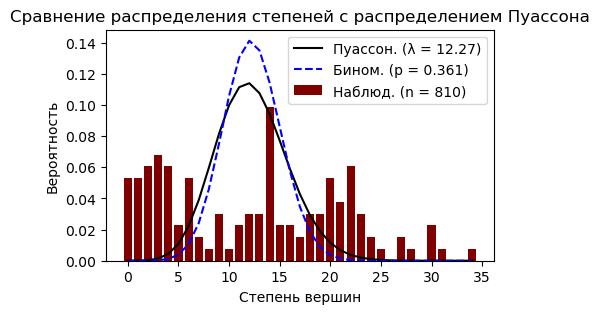

In [39]:
plt.figure(figsize = (5, 3))
plt.bar(k_unique, P_emp, color = 'maroon', label = f'Наблюд. (n = {len(G.edges())})')
plt.plot(k_range, P_pois, color = 'black', label = f'Пуассон. (λ = {lmbd:.2f})')
plt.plot(k_range, stats.binom.pmf(k_range, n, p_est), color = 'blue', linestyle='--', label = f'Бином. (p = {p_est:.3f})')
plt.xlabel('Степень вершин')
plt.ylabel('Вероятность')
plt.title('Сравнение распределения степеней с распределением Пуассона')
plt.legend()
plt.show()

Видно, что наблюдаемое распределение не укладывается ни в биномиальное, ни в пуассоновское => моя сеть действительно не похожа на модель Эрдёша-Реньи (т. е. не является случайным графом).

2. С моделью Барабаши-Альберт

Для того чтобы сравнить мой граф с моделью Барбаши-Альберта, проверю, соответствует ли его распределение степенному закону.

Если степени распределены по степенному закону, то в логарифмическом масштабе они будут укладываться в линию.

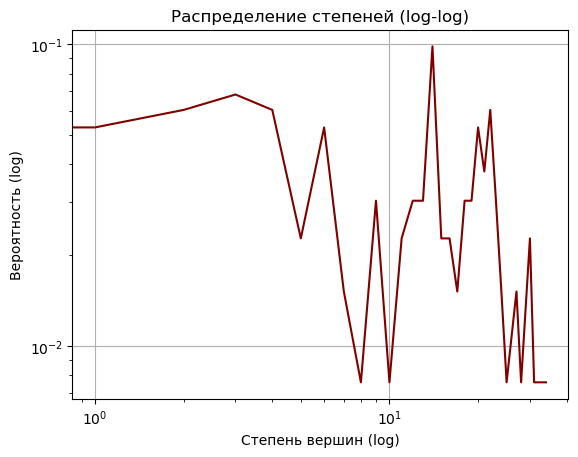

In [45]:
plt.loglog(k_unique, P_emp, color = 'maroon')
plt.xlabel('Степень вершин (log)')
plt.ylabel('Вероятность (log)')
plt.title('Распределение степеней (log-log)')
plt.grid()
plt.show()

Мой граф не похож на модель Барабаши-Альберт (и не обладает свойствами scale-free и предпочтительного присоединения).

3. Модель Ваттса-Строгаца

In [48]:
nodes, edges = Ggraph.number_of_nodes(), Ggraph.number_of_edges()
cluster, path = nx.average_clustering(Ggraph), 1 / (nx.global_efficiency(Ggraph))
p = (2 * edges) / (nodes * (nodes - 1))

In [49]:
clusters, paths = [], []
for _ in range(50):
    G1 = nx.erdos_renyi_graph(nodes, p)
    G1 = G1.subgraph(max(nx.connected_components(G1), key = len)).copy()
    if len(G1) > 1:
        clusters.append(nx.average_clustering(G1))
        paths.append(nx.average_shortest_path_length(G1))

cl_random = np.mean(clusters)
path_random = np.mean(paths)
sigma = (cluster / cl_random) / (path / path_random)

Проверим, какие признаки учтены.

In [51]:
all([cluster > 1.5 * cl_random, path < 1.5 * path_random, sigma > 1.5])

True

Моя сеть похожа на модель Ваттса-Строгаца, поскольку в ее гигантской компоненте:

- коэффициент кластеризации больше, чем в случайном графе
- средний путь короче
- сигма больше

### Центральность

Посчитаю основные меры центральностей и выведу топ-5 вершин для каждой.

Degree centrality

In [56]:
degree_central = nx.degree_centrality(G)
top_edges_d = sorted(degree_central, key = degree_central.get, reverse = True)[:5]
for i, node in enumerate(top_edges_d):
    centrality = degree_central[node]
    print(f'{i+1}. {friends_info.get(node, node)}: centrality = {centrality:.3f}')

1. Мария Красильщикова: centrality = 0.260
2. Ксения Григорьева: centrality = 0.237
3. Настя Сумеди: centrality = 0.229
4. Мариам Мубарек: centrality = 0.229
5. Александра Соловьева: centrality = 0.229


Closeness centrality

In [58]:
closeness_central = nx.closeness_centrality(G)
top_edges_c = sorted(closeness_central, key = closeness_central.get, reverse = True)[:5]
for i, node in enumerate(top_edges_c):
    centrality = closeness_central[node]
    print(f'{i+1}. {friends_info.get(node, node)}: centrality = {centrality:.3f}')

1. Дарья Соловьева: centrality = 0.265
2. Ксения Григорьева: centrality = 0.262
3. Мария Красильщикова: centrality = 0.257
4. Настя Сумеди: centrality = 0.253
5. Женя Столпникова: centrality = 0.249


Betwenness Centrality

In [60]:
betweenness_central = nx.betweenness_centrality(G)
top_edges_b = sorted(betweenness_central, key = betweenness_central.get, reverse = True)[:5]
for i, node in enumerate(top_edges_b):
    centrality = betweenness_central[node]
    print(f'{i+1}. {friends_info.get(node, node)}: centrality = {centrality:.3f}')

1. Дарья Соловьева: centrality = 0.072
2. Полина Меньшова: centrality = 0.067
3. Ксения Григорьева: centrality = 0.019
4. Женя Столпникова: centrality = 0.013
5. Мария Красильщикова: centrality = 0.011


Eigenvector centrality

In [62]:
eigenvector_central = nx.eigenvector_centrality(G, max_iter=150)
top_edges_e = sorted(eigenvector_central, key = eigenvector_central.get, reverse = True)[:5]
for i, node in enumerate(top_edges_e):
    centrality = eigenvector_central[node]
    print(f'{i+1}. {friends_info.get(node, node)}: centrality = {centrality:.3f}')

1. Мария Красильщикова: centrality = 0.258
2. Александра Соловьева: centrality = 0.243
3. Мариам Мубарек: centrality = 0.242
4. Денис Ермаков: centrality = 0.220
5. Дарья Соловьева: centrality = 0.199


In [63]:
table = []

for i in range(5):
    row = {
        'Ранг': i+1,
        'Degree': friends_info.get(top_edges_d[i], top_edges_d[i]),
        'Closeness': friends_info.get(top_edges_c[i], top_edges_c[i]),
        'Betweenness': friends_info.get(top_edges_b[i], top_edges_b[i]),
        'Eigenvector': friends_info.get(top_edges_e[i], top_edges_e[i])}
    table.append(row)

df = pd.DataFrame(table)
df

,Ранг,Degree,Closeness,Betweenness,Eigenvector
0,1,Мария Красильщикова,Дарья Соловьева,Дарья Соловьева,Мария Красильщикова
1,2,Ксения Григорьева,Ксения Григорьева,Полина Меньшова,Александра Соловьева
2,3,Настя Сумеди,Мария Красильщикова,Ксения Григорьева,Мариам Мубарек
3,4,Мариам Мубарек,Настя Сумеди,Женя Столпникова,Денис Ермаков
4,5,Александра Соловьева,Женя Столпникова,Мария Красильщикова,Дарья Соловьева


Лидером по появлению в топах стала вершина Мария Красильщикова.

### Корреляция центральностей

Посмотрим на отношение между центральностями. Попарно измерим корреляцию Пирсона.

In [67]:
centralities = [list(degree_central.values()),
        list(closeness_central.values()),
        list(betweenness_central.values()),
        list(eigenvector_central.values())]
names = ['Degree', 'Closeness', 'Betweenness', 'Eigenvector']

In [68]:
for i in range(4):
    print(f'{names[i]:11s}', end = '')
    for j in range(4):
        corr = np.corrcoef(centralities[i], centralities[j])[0,1]
        print(f"{corr:7.2f}", end='')
    print()

Degree        1.00   0.84   0.31   0.57
Closeness     0.84   1.00   0.28   0.48
Betweenness   0.31   0.28   1.00   0.20
Eigenvector   0.57   0.48   0.20   1.00


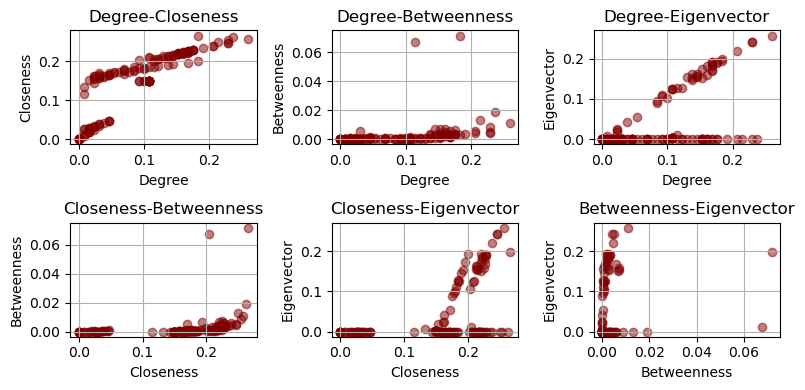

In [69]:
fig, axs = plt.subplots(2, 3, figsize = (8, 4))
idx = 0
for i in range(4):
    for j in range(i+1, 4):
        row, col = idx //  3, idx % 3
        axs[row, col].scatter(centralities[i], centralities[j], color = 'maroon', alpha = .5)
        corr = np.corrcoef(centralities[i], centralities[j])
        axs[row, col].set_title(f'{names[i]}-{names[j]}')
        axs[row, col].set_xlabel(names[i])
        axs[row, col].set_ylabel(names[j])
        axs[row, col].grid(True)
        idx += 1
        
plt.tight_layout()
plt.show()

Почти все меры обладают низкой или умеренной корреляцией.
Сильная корреляция прослеживается между мерами Degree и Closeness. Это кажется мне достаточно логичным, поскольку множество прямых связей обычно означает, что путь до других узлов должен быть коротким.

Самая незначительная корреляция в паре Betwenness-Eigenvector. Это означает, что вершина может быть критически важна для соединения частей сети, но сам при этом не обязательно связана с самыми влиятельнами вершинами.

### Визуализация центральностей

Подсветим вершины, которые попали хотя бы в один из топов центральностей.

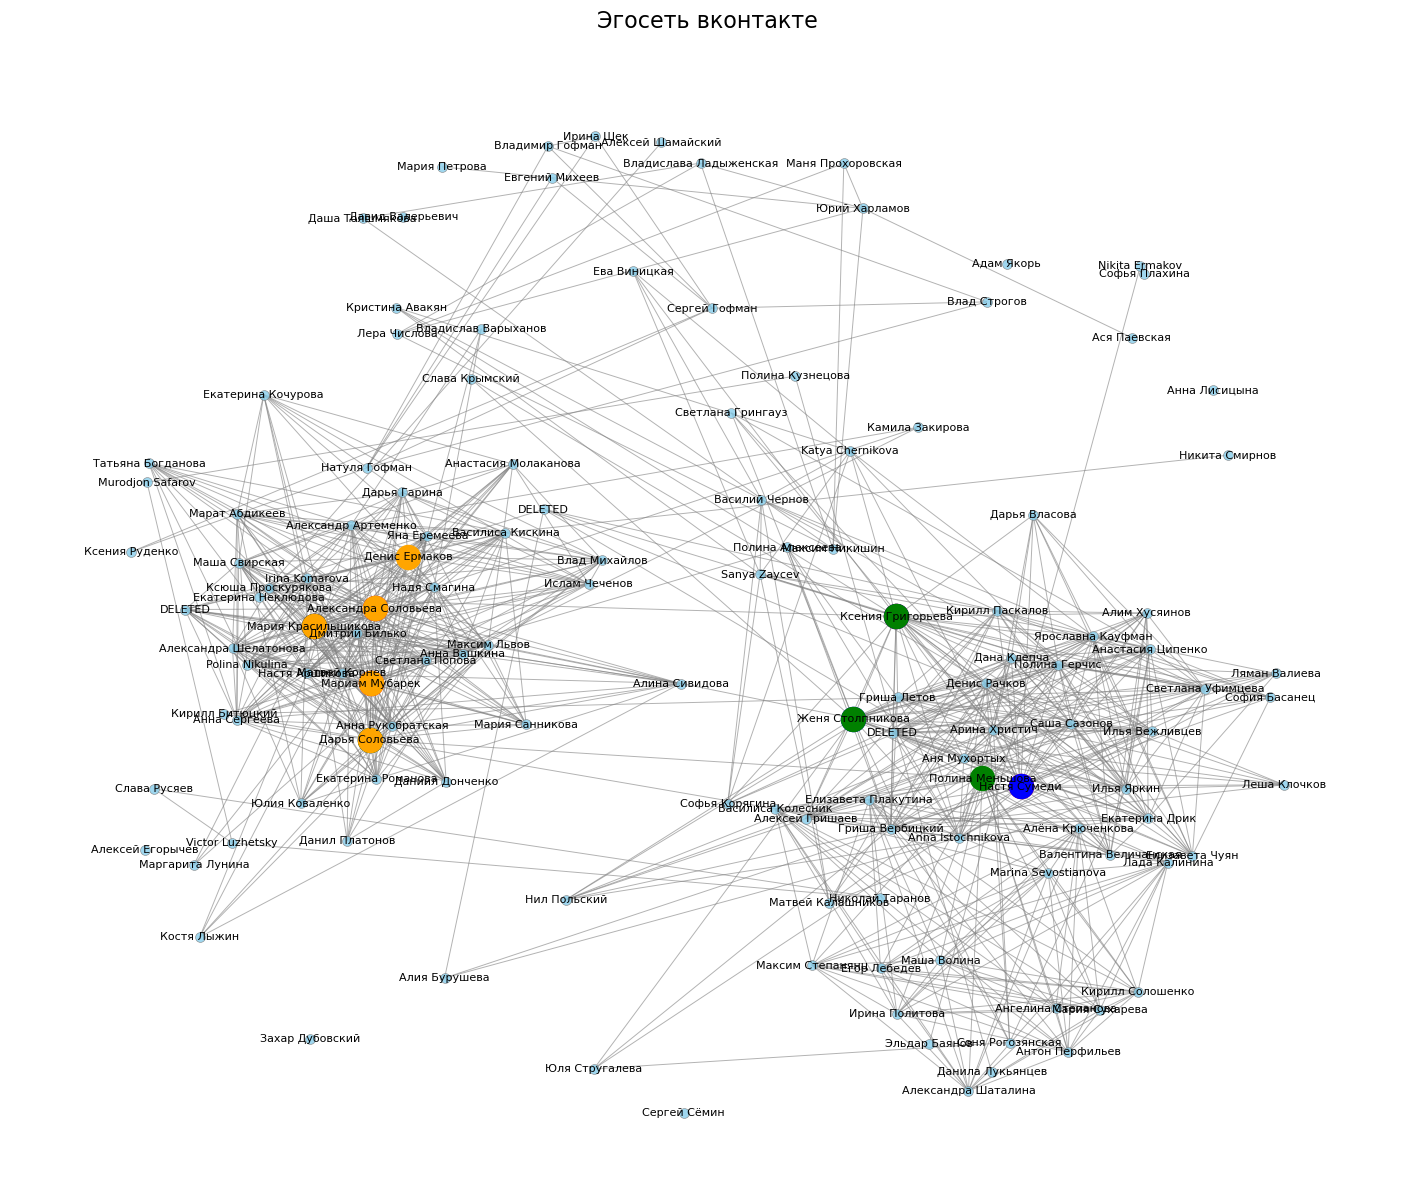

In [73]:
plt.figure(figsize=(18, 15))

nx.draw_networkx_nodes(G, pos, node_size = 50, node_color = 'skyblue', alpha = .8, edgecolors = 'gray', linewidths = .5)
nx.draw_networkx_nodes(G, pos, nodelist=list(top_edges_d), node_color='red')
nx.draw_networkx_nodes(G, pos, nodelist=list(top_edges_c), node_color='blue')
nx.draw_networkx_nodes(G, pos, nodelist=list(top_edges_b), node_color='green')
nx.draw_networkx_nodes(G, pos, nodelist=list(top_edges_e), node_color='orange')
nx.draw_networkx_edges(G, pos, width = 0.7, edge_color = 'gray', alpha = 0.6)

labels = nx.get_node_attributes(G, 'label')
nx.draw_networkx_labels(G, pos, labels, font_size = 8, font_color = 'black')

plt.title('Эгосеть вконтакте', fontsize = 16)
plt.axis('off')
plt.show()

## Определение сообществ

Воспользуемся несколькими алгоритмами для поиска сообществ.

### Clique detection

Параметр k здесь задан случайным образом, ниже будет приведен другой, более обоснованный.

In [78]:
kcc = nx.community.k_clique_communities(G, k = 4)

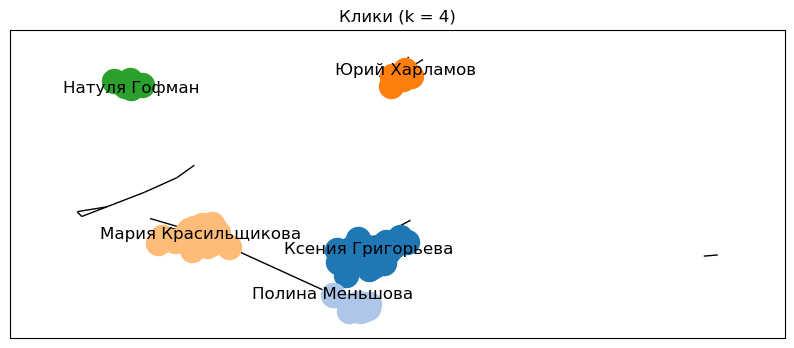

In [79]:
plt.figure(figsize=(10, 4))
pos = nx.spring_layout(G, seed = 42)

for i, comm in enumerate(kcc):
    nx.draw_networkx_nodes(G, pos, nodelist = list(comm), node_color = [plt.cm.tab20(i)])
    labeled = max(list(comm), key = lambda x: G.degree(x))
    nx.draw_networkx_labels(G, pos, {labeled: friends_info[labeled]})

nx.draw_networkx_edges(G, pos)
plt.title(f'Клики (k = 4)')
plt.show()

### Girvan Newman algorithm

Выведем первые 4 разбиения.

In [82]:
gna = nx.community.girvan_newman(G)

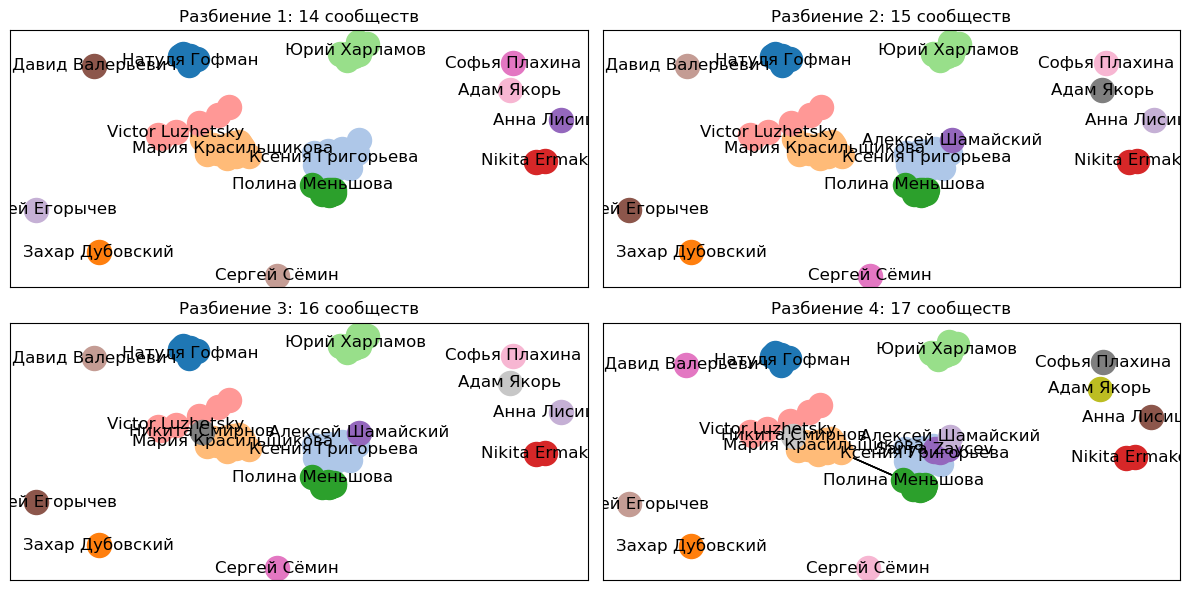

In [83]:
fig, axes = plt.subplots(2, 2, figsize = (12, 6))
for i, (ax, comms) in enumerate(zip(axes.flatten(), gna)):
    if i >= 4:
        break
    pos = nx.spring_layout(G, seed = 42)
    comms = list(comms) 
    
    for j, comm in enumerate(comms):
        nx.draw_networkx_nodes(G, pos, nodelist = list(comm), node_color = [plt.cm.tab20(j)], ax = ax)
        labeled = max(comm, key = lambda x: G.degree(x))
        nx.draw_networkx_labels(G, pos, {labeled: friends_info[labeled]}, ax = ax)
    
    nx.draw_networkx_edges(G, pos)
    ax.set_title(f'Разбиение {i+1}: {len(comms)} сообществ')

plt.tight_layout()
plt.show()

### Louvain method

In [85]:
lv = nx.community.louvain_communities(G)

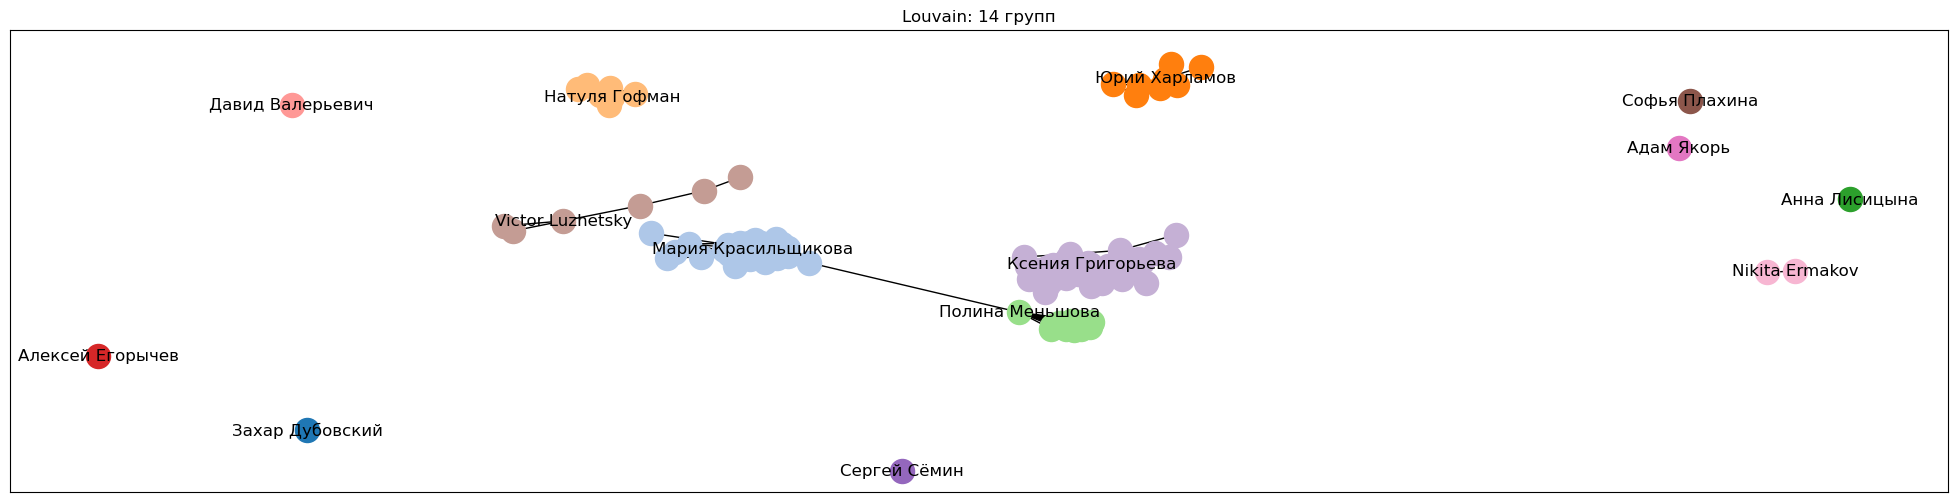

In [86]:
plt.figure(figsize=(25, 6))
pos = nx.spring_layout(G, seed = 42)

for i, comm in enumerate(lv):
    nx.draw_networkx_nodes(G, pos, nodelist=list(comm), node_color=[plt.cm.tab20(i)])

nx.draw_networkx_edges(G, pos)

labels = {}
for i, comm in enumerate(lv):
    if comm:
        central_node = max(comm, key=lambda x: G.degree(x))
        labels[central_node] = friends_info[central_node]

nx.draw_networkx_labels(G, pos, labels)

plt.title(f'Louvain: {len(lv)} групп')
plt.show()

### Modularity

Посчитаю модулярность для алгоритмов Louvian и Girvan-Newman. Считать модулярность k_clique_communities не буду, потому что этот подход создает пересекающиеся сообщества.

In [89]:
results = {}

In [90]:
lv = nx.community.louvain_communities(G)
lv_mod = nx.community.modularity(G, lv)
results['Louvain'] = {'communities': lv, 'modularity': lv_mod}

In [91]:
gna = nx.community.girvan_newman(G)
best_gn_mod = -1
best_gn_comms = None

for communities in gna:
    communities_list = list(communities)
    current_mod = nx.community.modularity(G, communities_list)
    
    if current_mod > best_gn_mod:
        best_gn_mod = current_mod
        best_gn_comms = communities_list
    
results['Girvan-Newman'] = {'communities': best_gn_comms, 'modularity': best_gn_mod}

Для подсчета модулярности пересекающихся сообществ я нашел библиотеку cdlib и меру overlap modularity.

In [93]:
communities_generator = algorithms.kclique(G, k = 4)

mod_overlap = evaluation.modularity_overlap(G, communities_generator)

print(f'Сеть с {G.number_of_nodes()} вершинами и {G.number_of_edges()} ребрами.')
print(f'Количество найденных клик: {len(communities_generator.communities)}')
print(f'Модулярность для пересекающихся сообществ: {mod_overlap.score:.4f}')

Сеть с 132 вершинами и 810 ребрами.
Количество найденных клик: 5
Модулярность для пересекающихся сообществ: 0.6117


При k = 4 образуется 5 клик, мера пересекающейся модулярности достаточно высокая. Это большие группы, с плотными ядрами. В этом больше смысла, чем в 14 сообществах, которые получились в результате работы двух других алгоритмов (см. таблицу ниже), потому что мы не рассматриваем в качестве клики единичные вершины. В бытовом понимании слова "сообщество" такие люди и не станут образующими новые сообщества.

In [95]:
for algorythm, data in results.items():
    print(f'{algorythm:20} | Модулярность: {data["modularity"]:.4f} | Сообществ: {len(data["communities"])}')

Louvain              | Модулярность: 0.6345 | Сообществ: 14
Girvan-Newman        | Модулярность: 0.6345 | Сообществ: 14


Показатели модулярности для двух других алгоритмов в свою очередь выше среднего. Это говорит о том, что в моей сети есть ярко выраженные сообщества.

В действительности так и есть: мои друзья объединены местом, откуда я их знаю: два университета, работа, школа. Большое количество сообществ связано с тем, что у меня есть не связанные с остальными вершинами друзья из маленьких сообществ (подъезд, конференция и пр.)

### NMI

Сравнивать модулярность для пере- и непересекающихся сообществ не получается, но оценить алгоритмы все-таки хочется, поэтому я воспользуюсь метрикой normalized mutual information. Создам функцию для сравнения k_clique с эталонным выделением.

Склерн, который я использую для подсчета, работает с метками, а не с сообществами, поэтому напишу функцию, которая будет конвертировать сообщества в метки.

In [100]:
def comms2labels(G, comms):
    labels = {}
    for i, c in enumerate(comms):
        for node in c:
            labels[node] = i
    return [labels[node] for node in G.nodes()]

In [101]:
def nmi_plot(base_algo, k_range):
    base_algo_labels = comms2labels(G, list(base_algo))
    nmi_scores = []
    for k in k_range:
        kcc = nx.community.k_clique_communities(G, k)
        kcc_comms = []
        used = set()
        for c in list(kcc):
            new = [n for n in c if n not in used]
            if new:
                kcc_comms.append(set(new))
                used.update(new)
        for n in set(G.nodes()) - used:
            kcc_comms.append({n})
        
        kcc_labels = comms2labels(G, kcc_comms)
        nmi = normalized_mutual_info_score(base_algo_labels, kcc_labels)
        nmi_scores.append(nmi)
        
    plt.figure(figsize=(11, 4))
    plt.plot(k_range, nmi_scores, color = 'maroon', marker = 'o', linewidth = 2, markersize = 8)
    plt.xlabel('Значение k в k-clique', fontsize = 12)
    plt.ylabel('NMI эталон', fontsize = 12)
    plt.title(f'Сходство k-clique с эталоном при разных k', fontsize = 14)
    for k, nmi in zip(k_range, nmi_scores):
        plt.text(k, nmi + 0.02, f'{nmi:.3f}', ha = 'center', va = 'bottom', fontsize = 10)
    plt.grid(True, alpha=0.3)
    plt.xticks(k_range)
    plt.show()

Сравню nmi в k_clique с louvian и girvan-newman. для алгоритма girvan-newman взял второе по списку разбиение на сообщества, потому что первое на отличается от louvian.

In [103]:
k_range = list(range(2, 21))

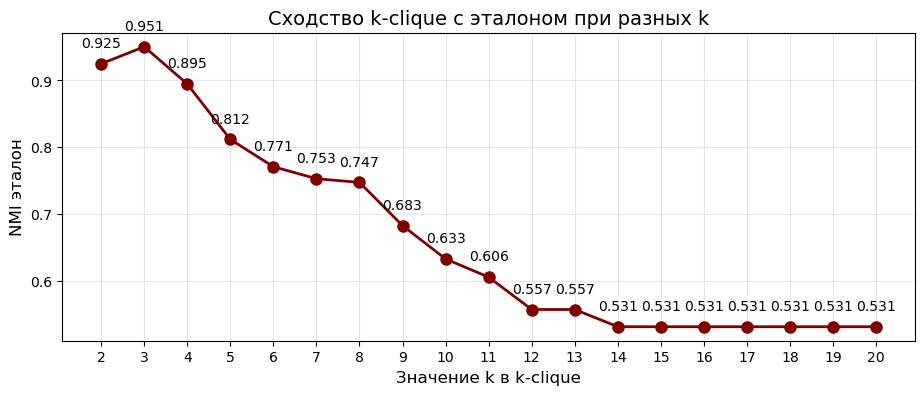

In [104]:
nmi_plot(lv, k_range)

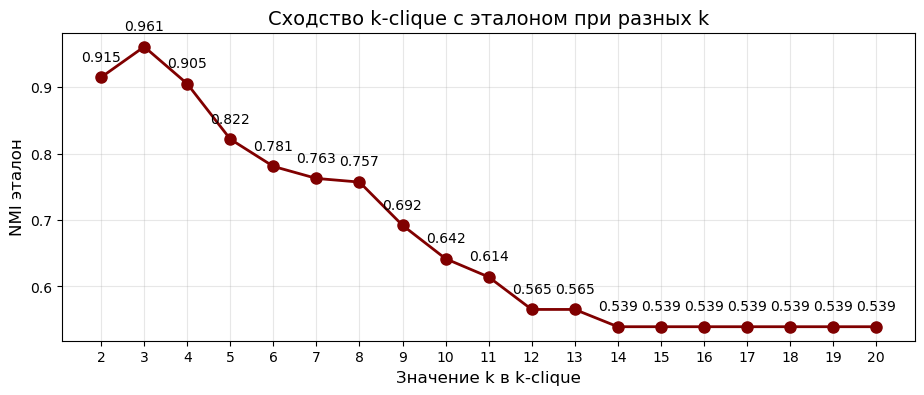

In [105]:
gna = nx.community.girvan_newman(G)
nmi_plot(list(gna)[1], k_range)

Кажется, наилучшего результата в выделении клик можно добиться при размере клик равном 3. Проверю

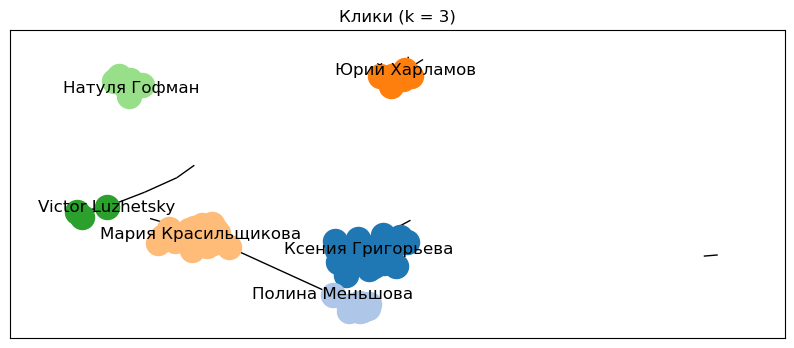

In [107]:
kcc = nx.community.k_clique_communities(G, k = 3)
plt.figure(figsize=(10, 4))
pos = nx.spring_layout(G, seed = 42)

for i, comm in enumerate(kcc):
    nx.draw_networkx_nodes(G, pos, nodelist = list(comm), node_color = [plt.cm.tab20(i)])
    labeled = max(list(comm), key = lambda x: G.degree(x))
    nx.draw_networkx_labels(G, pos, {labeled: friends_info[labeled]})

nx.draw_networkx_edges(G, pos)
plt.title(f'Клики (k = 3)')
plt.show()

Появилась новая клика!

Попробую пересчитать модулярность для нового k.

In [109]:
communities_generator = algorithms.kclique(G, k = 3)

mod_overlap = evaluation.modularity_overlap(G, communities_generator)
print(f'Количество найденных клик: {len(communities_generator.communities)}')
print(f'Модулярность для пересекающихся сообществ: {mod_overlap.score:.4f}')

Количество найденных клик: 6
Модулярность для пересекающихся сообществ: 0.6301


При k = 3 показатель пересекающейся модулярности немного вырос. Появилась одна новая клика.

## Выводы

Я проанализировал сеть, составленную из моих друзей. Полученные результаты кажутся мне вполне естественными и правдоподобными. Несколько выводов:

- в моей сети друзья, которых я завел в одинаковых местах, с бОльшей вероятностью дружат между собой. На таком же основании образуются и сообщества
- самым частым элементом в списках важных вершин стала моя преподавательница: у нее в друзьях много студентов из разных курсов / потоков / годов выпуска, некоторые из которых оказались и у меня в друзьях.
- Сильно коррелирующей оказалась пара Degree-Closeness, слабо коррелирует пара Betweenness-Eigenvector, остальные пары продемонстрировали средней интенсивности положительную корреляцию. Мне снова кажется, что такой результат можно было бы ожидать. Все метрики так или иначе связаны с вершинами, находящимися не на периферии моей сети.